In [1]:
import sys
from pathlib import Path

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Notebook directory:", Path.cwd())

Python: 3.12.14 (main, Aug 25 2026, 13:50:33) [Clang 22.1.3 ]
Executable: /Users/rathore/dev/shailsr/ai-engineering-from-scratch/.venv/bin/python3
Notebook directory: /Users/rathore/dev/shailsr/ai-engineering-from-scratch/personal-notebooks/phase-00


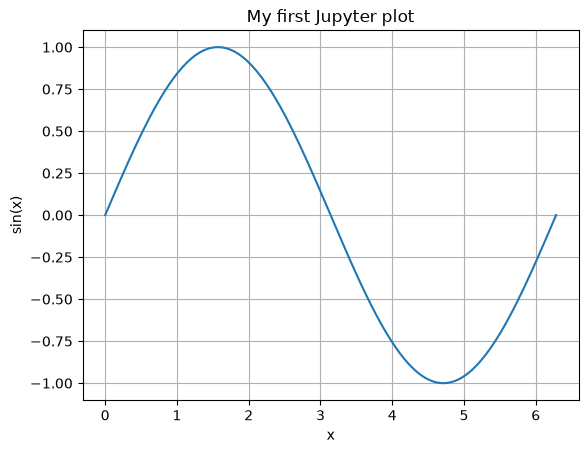

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

plt.plot(x, y)
plt.title("My first Jupyter plot")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()

In [3]:
import numpy as np
data = np.random.randn(1000)
data.mean(), data.std()

(np.float64(-0.017278673638394942), np.float64(1.0269330936848686))

In [4]:
%timeit np.random.randn(10000)

107 μs ± 755 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [5]:
## Step 4 — Jupyter magic commands

In [6]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

In [7]:
%timeit np.random.randn(10_000)

108 μs ± 628 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [8]:
%%time

a = np.random.randn(1000, 1000)
result = a @ a

CPU times: user 18 ms, sys: 3.17 ms, total: 21.2 ms
Wall time: 15.2 ms


In [9]:
!pwd
!python --version

/Users/rathore/dev/shailsr/ai-engineering-from-scratch/personal-notebooks/phase-00
Python 3.12.14


In [10]:
import subprocess
import sys

subprocess.run(
    [
        "uv",
        "pip",
        "install",
        "--python",
        sys.executable,
        "pandas",
        "scikit-learn",
    ],
    check=True,
)

Using Python 3.12.14 environment at: /Users/rathore/dev/shailsr/ai-engineering-from-scratch/.venv
Checked 2 packages in 4ms


CompletedProcess(args=['uv', 'pip', 'install', '--python', '/Users/rathore/dev/shailsr/ai-engineering-from-scratch/.venv/bin/python3', 'pandas', 'scikit-learn'], returncode=0)

In [11]:
## Step 5 — Rich inline output

In [12]:
import pandas as pd

df = pd.DataFrame({
    "model": ["Linear", "Random Forest", "Neural Net"],
    "accuracy": [0.72, 0.89, 0.94],
    "training_time": [0.1, 2.3, 45.6],
})

df

,model,accuracy,training_time
0,Linear,0.72,0.1
1,Random Forest,0.89,2.3
2,Neural Net,0.94,45.6


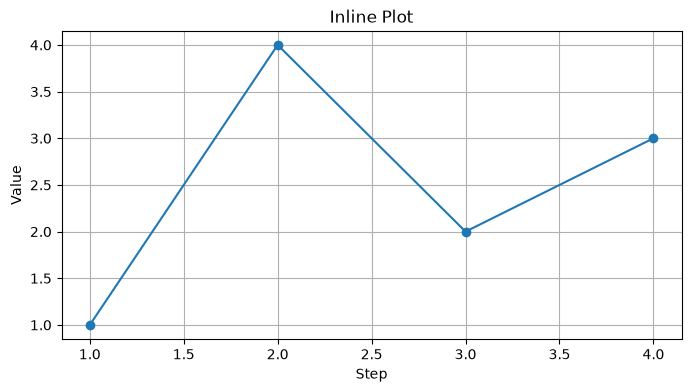

In [13]:
plt.figure(figsize=(8, 4))
plt.plot([1, 2, 3, 4], [1, 4, 2, 3], marker="o")
plt.title("Inline Plot")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [14]:
plt.figure(figsize=(6, 3))
plt.plot([1, 2, 3], [1, 4, 2])
plt.title("Saved notebook image")
plt.savefig("demo-plot.png", dpi=120, bbox_inches="tight")
plt.close()

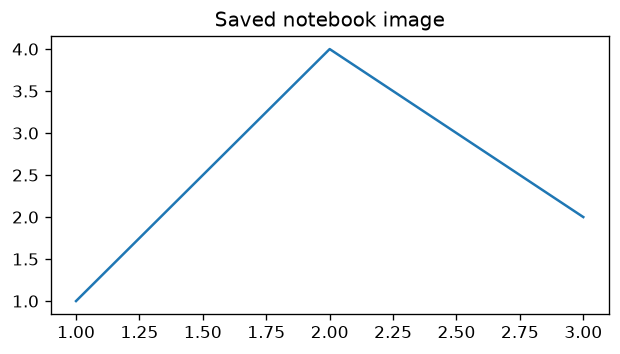

In [15]:
from IPython.display import Image, display

display(Image(filename="demo-plot.png"))

In [16]:
%env AIEFS_NOTEBOOK_MODE=learning

env: AIEFS_NOTEBOOK_MODE=learning


In [17]:
%env AIEFS_NOTEBOOK_MODE

'learning'

In [18]:
import os

print(
    "CUDA_VISIBLE_DEVICES:",
    os.environ.get("CUDA_VISIBLE_DEVICES", "Not set — expected on Apple MPS"),
)

CUDA_VISIBLE_DEVICES: Not set — expected on Apple MPS


In [19]:
import pandas as pd

df = pd.DataFrame({
    "model": ["Linear", "Random Forest", "Neural Net"],
    "accuracy": [0.72, 0.89, 0.94],
    "training_time": [0.1, 2.3, 45.6],
})

df

,model,accuracy,training_time
0,Linear,0.72,0.1
1,Random Forest,0.89,2.3
2,Neural Net,0.94,45.6


In [20]:
## Exercise 1 — Python list versus NumPy

In [21]:
import random
import numpy as np

In [22]:
%timeit [random.random() for _ in range(100_000)]

2.55 ms ± 21.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [23]:
%timeit np.random.random(100_000)

240 μs ± 13.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [24]:
### Observation

### NumPy creates the random-number array faster because it performs the operation
### in compiled, vectorized code rather than executing a Python loop for every item.

In [25]:
## Exercise 2 — Load and visualize CSV data

In [26]:
from pathlib import Path

csv_path = Path("model-results.csv")

csv_path.write_text(
    """model,accuracy,training_time
Linear,0.72,0.1
Random Forest,0.89,2.3
Neural Net,0.94,45.6
"""
)

print("Created:", csv_path.resolve())

Created: /Users/rathore/dev/shailsr/ai-engineering-from-scratch/personal-notebooks/phase-00/model-results.csv


In [27]:
import pandas as pd

results_df = pd.read_csv(csv_path)
results_df

,model,accuracy,training_time
0,Linear,0.72,0.1
1,Random Forest,0.89,2.3
2,Neural Net,0.94,45.6


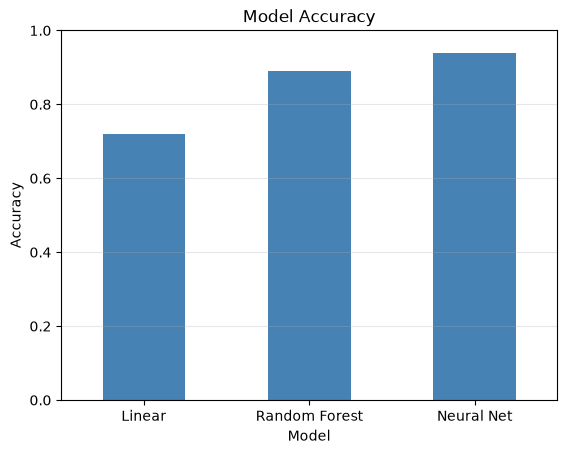

In [28]:
import matplotlib.pyplot as plt

ax = results_df.plot(
    kind="bar",
    x="model",
    y="accuracy",
    ylim=(0, 1),
    legend=False,
    color="steelblue",
)

ax.set_title("Model Accuracy")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()